# Attention Is All You Need (Transformer)

Implementing the Transformer architecture from scratch in PyTorch, following Vaswani et al. (2017).

**Paper:** https://arxiv.org/abs/1706.03762

This notebook builds a mini Transformer encoder-decoder from the ground up — scaled dot-product attention, multi-head attention, positional encoding, encoder/decoder layers — and trains it on a toy sequence copy task with full attention visualization.

## 1. Setup & Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import math
import random

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 2. Toy Dataset — Sequence Copy Task

We create a simple synthetic dataset where each sample is a random sequence of integers.
The task is to **copy** the input sequence to the output (a classic test of whether the model
can learn to attend to the correct source positions).

In [2]:
# Special tokens
PAD_TOKEN = 0
BOS_TOKEN = 1
EOS_TOKEN = 2
UNK_TOKEN = 3
VOCAB_BASE = 4  # first 4 IDs are special tokens
VOCAB_SIZE_DATA = 10  # 10 real data tokens (IDs 4..13)
VOCAB_SIZE = VOCAB_BASE + VOCAB_SIZE_DATA  # 14 total

class CopyTaskDataset(Dataset):
    """Generates random integer sequences for the copy task."""
    def __init__(self, num_samples=5000, min_len=5, max_len=12, seed=42):
        self.rng = np.random.RandomState(seed)
        self.data = []
        for _ in range(num_samples):
            seq_len = self.rng.randint(min_len, max_len + 1)
            tokens = self.rng.randint(VOCAB_BASE, VOCAB_BASE + VOCAB_SIZE_DATA, size=seq_len).tolist()
            self.data.append(tokens)
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        src = self.data[idx]
        # Target is the same sequence wrapped with BOS/EOS
        tgt = [BOS_TOKEN] + src[:] + [EOS_TOKEN]
        return torch.tensor(src, dtype=torch.long), torch.tensor(tgt, dtype=torch.long)

def collate_fn(batch):
    src_seqs, tgt_seqs = zip(*batch)
    src_padded = nn.utils.rnn.pad_sequence(src_seqs, batch_first=True, padding_value=PAD_TOKEN)
    tgt_padded = nn.utils.rnn.pad_sequence(tgt_seqs, batch_first=True, padding_value=PAD_TOKEN)
    return src_padded, tgt_padded

# Create datasets
train_dataset = CopyTaskDataset(num_samples=4000, min_len=5, max_len=12, seed=SEED)
test_dataset = CopyTaskDataset(num_samples=500, min_len=5, max_len=12, seed=SEED+999)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn)

# Show a sample
src_sample, tgt_sample = train_dataset[0]
print(f'Sample source: {src_sample.tolist()}')
print(f'Sample target: {tgt_sample.tolist()}')
print(f'Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}')
print(f'Vocab size: {VOCAB_SIZE}')

Sample source: [7, 11, 8, 10, 13, 6, 10, 11, 8, 7, 11]
Sample target: [1, 7, 11, 8, 10, 13, 6, 10, 11, 8, 7, 11, 2]
Train samples: 4000, Test samples: 500
Vocab size: 14


## 3. Positional Encoding

Since self-attention is permutation-invariant, we inject positional information using
sinusoidal encodings as described in the paper:

$$PE_{(pos, 2i)} = \sin(pos / 10000^{2i/d_{model}})$$
$$PE_{(pos, 2i+1)} = \cos(pos / 10000^{2i/d_{model}})$$

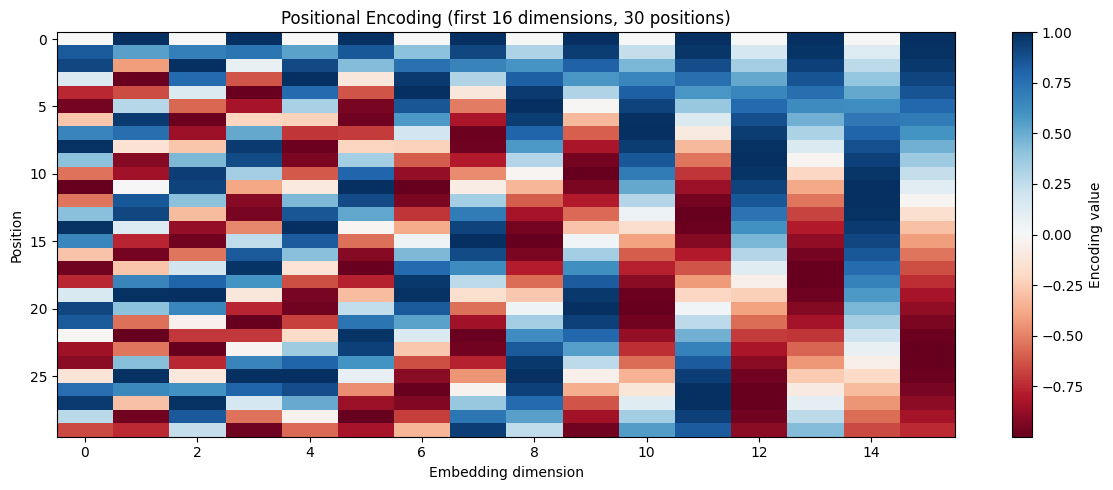

Positional encoding visualization saved.


In [3]:
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding from 'Attention Is All You Need'."""
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        # x: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return x

# Visualize positional encoding
d_model_demo = 64
pe_demo = PositionalEncoding(d_model_demo, max_len=50)
pe_values = pe_demo.pe[0, :30, :16].numpy()  # first 30 positions, first 16 dims

plt.figure(figsize=(12, 5))
plt.imshow(pe_values, cmap='RdBu', aspect='auto', interpolation='nearest')
plt.colorbar(label='Encoding value')
plt.xlabel('Embedding dimension')
plt.ylabel('Position')
plt.title('Positional Encoding (first 16 dimensions, 30 positions)')
plt.tight_layout()
plt.savefig('positional_encoding.png', dpi=150, bbox_inches='tight')
plt.show()
print('Positional encoding visualization saved.')

## 4. Scaled Dot-Product Attention

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

The scaling factor $1/\sqrt{d_k}$ prevents the dot products from growing large,
which would push the softmax into low-gradient regions.

In [4]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Scaled dot-product attention.
    
    Args:
        Q: (batch, heads, seq_q, d_k)
        K: (batch, heads, seq_k, d_k)
        V: (batch, heads, seq_k, d_v)
        mask: (batch, 1, seq_q, seq_k) or None — True at masked positions
    Returns:
        output: (batch, heads, seq_q, d_v)
        attention_weights: (batch, heads, seq_q, seq_k)
    """
    d_k = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)  # (B, H, Lq, Lk)
    
    if mask is not None:
        scores = scores.masked_fill(mask, float('-inf'))
    
    attention_weights = F.softmax(scores, dim=-1)  # (B, H, Lq, Lk)
    output = torch.matmul(attention_weights, V)  # (B, H, Lq, d_v)
    
    return output, attention_weights

## 5. Multi-Head Attention

Instead of a single attention function, the model projects Q/K/V into $h$ parallel subspaces,
attends in each independently, then concatenates and projects back.

$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, ..., \text{head}_h)W^O$$
where $\text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)$

In [5]:
class MultiHeadAttention(nn.Module):
    """Multi-head attention with learned linear projections."""
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, f'd_model ({d_model}) must be divisible by num_heads ({num_heads})'
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)
    
    def forward(self, query, key, value, mask=None):
        """
        Args:
            query, key, value: (batch, seq_len, d_model)
            mask: (batch, 1, seq_q, seq_k) or None
        Returns:
            output: (batch, seq_len, d_model)
            attention_weights: (batch, heads, seq_q, seq_k)
        """
        batch_size = query.size(0)
        
        # Project and split into heads: (B, L, d_model) -> (B, H, L, d_k)
        Q = self.W_q(query).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(key).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(value).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        
        # Apply attention
        attn_output, attn_weights = scaled_dot_product_attention(Q, K, V, mask)
        
        # Concatenate heads: (B, H, L, d_k) -> (B, L, d_model)
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        
        # Final projection
        output = self.W_o(attn_output)
        
        return output, attn_weights

## 6. Position-wise Feed-Forward Network

$$\text{FFN}(x) = \max(0, xW_1 + b_1)W_2 + b_2$$

Applied to each position independently (shared across positions).

In [6]:
class PositionwiseFeedForward(nn.Module):
    """Position-wise feed-forward network: two linear layers with ReLU."""
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
    
    def forward(self, x):
        # x: (batch, seq_len, d_model)
        return self.fc2(F.relu(self.fc1(x)))

## 7. Encoder Layer

Each encoder layer has two sub-layers:
1. Multi-head self-attention
2. Position-wise feed-forward

Each sub-layer is wrapped with a residual connection and layer normalization:
$\text{LayerNorm}(x + \text{Sublayer}(x))$

In [7]:
class EncoderLayer(nn.Module):
    """Single Transformer encoder layer."""
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PositionwiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
    
    def forward(self, x, src_mask=None):
        """
        Args:
            x: (batch, seq_len, d_model)
            src_mask: (batch, 1, 1, seq_len) padding mask or None
        Returns:
            x: (batch, seq_len, d_model)
            attn_weights: (batch, heads, seq_len, seq_len)
        """
        # Sub-layer 1: self-attention with residual + norm
        attn_output, attn_weights = self.self_attn(x, x, x, mask=src_mask)
        x = self.norm1(x + self.dropout1(attn_output))
        
        # Sub-layer 2: feed-forward with residual + norm
        ffn_output = self.ffn(x)
        x = self.norm2(x + self.dropout2(ffn_output))
        
        return x, attn_weights

## 8. Decoder Layer

Each decoder layer has three sub-layers:
1. Masked multi-head self-attention (causal mask prevents looking ahead)
2. Cross-attention over encoder output (encoder-decoder attention)
3. Position-wise feed-forward

Each with residual + LayerNorm.

In [8]:
class DecoderLayer(nn.Module):
    """Single Transformer decoder layer."""
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PositionwiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)
    
    def forward(self, x, enc_output, tgt_mask=None, src_mask=None):
        """
        Args:
            x: (batch, seq_len_tgt, d_model)
            enc_output: (batch, seq_len_src, d_model)
            tgt_mask: (batch, 1, seq_len_tgt, seq_len_tgt) causal+padding mask
            src_mask: (batch, 1, 1, seq_len_src) padding mask
        Returns:
            x: (batch, seq_len_tgt, d_model)
            self_attn_weights, cross_attn_weights
        """
        # Sub-layer 1: masked self-attention
        self_attn_output, self_attn_weights = self.self_attn(x, x, x, mask=tgt_mask)
        x = self.norm1(x + self.dropout1(self_attn_output))
        
        # Sub-layer 2: cross-attention over encoder output
        cross_attn_output, cross_attn_weights = self.cross_attn(x, enc_output, enc_output, mask=src_mask)
        x = self.norm2(x + self.dropout2(cross_attn_output))
        
        # Sub-layer 3: feed-forward
        ffn_output = self.ffn(x)
        x = self.norm3(x + self.dropout3(ffn_output))
        
        return x, self_attn_weights, cross_attn_weights

## 9. Full Transformer Model

Assembling the complete encoder-decoder Transformer:
- Source/target embeddings (shared weights, scaled by √d_model)
- Positional encoding
- N encoder layers + N decoder layers
- Final linear projection to vocabulary size

In [9]:
class Transformer(nn.Module):
    """Full Transformer encoder-decoder model."""
    def __init__(self, vocab_size, d_model=64, num_heads=4, d_ff=128,
                 num_encoder_layers=2, num_decoder_layers=2, dropout=0.05, max_len=50):
        super().__init__()
        self.d_model = d_model
        
        # Shared embedding (input + output + pre-softmax)
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_TOKEN)
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        
        # Encoder and decoder stacks
        self.encoder_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_encoder_layers)
        ])
        self.decoder_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_decoder_layers)
        ])
        
        self.dropout = nn.Dropout(dropout)
        
        # Output projection (tied with embedding)
        self.output_proj = nn.Linear(d_model, vocab_size, bias=False)
        self.output_proj.weight = self.embedding.weight  # weight tying
        
        # Store attention weights for visualization
        self.enc_attn_weights = []
        self.dec_self_attn_weights = []
        self.dec_cross_attn_weights = []
    
    def encode(self, src, src_mask=None):
        """Encode source sequence."""
        x = self.embedding(src) * math.sqrt(self.d_model)
        x = self.pos_encoding(x)
        x = self.dropout(x)
        
        self.enc_attn_weights = []
        for layer in self.encoder_layers:
            x, attn = layer(x, src_mask)
            self.enc_attn_weights.append(attn)
        
        return x
    
    def decode(self, tgt, enc_output, tgt_mask=None, src_mask=None):
        """Decode target sequence given encoder output."""
        x = self.embedding(tgt) * math.sqrt(self.d_model)
        x = self.pos_encoding(x)
        x = self.dropout(x)
        
        self.dec_self_attn_weights = []
        self.dec_cross_attn_weights = []
        for layer in self.decoder_layers:
            x, self_attn, cross_attn = layer(x, enc_output, tgt_mask, src_mask)
            self.dec_self_attn_weights.append(self_attn)
            self.dec_cross_attn_weights.append(cross_attn)
        
        return x
    
    def forward(self, src, tgt, src_mask=None, tgt_mask=None):
        """Full forward pass (training)."""
        enc_output = self.encode(src, src_mask)
        dec_output = self.decode(tgt, enc_output, tgt_mask, src_mask)
        logits = self.output_proj(dec_output)
        return logits
    
    @torch.no_grad()
    def greedy_decode(self, src, max_len=20, src_mask=None):
        """Autoregressive greedy decoding for inference."""
        batch_size = src.size(0)
        device = src.device
        
        enc_output = self.encode(src, src_mask)
        
        # Start with BOS token
        tgt = torch.full((batch_size, 1), BOS_TOKEN, dtype=torch.long, device=device)
        
        for step in range(max_len):
            tgt_mask = make_causal_mask(tgt.size(1), device).unsqueeze(0).expand(batch_size, -1, -1, -1)
            dec_output = self.decode(tgt, enc_output, tgt_mask, src_mask)
            logits = self.output_proj(dec_output[:, -1:, :])  # last position
            next_token = logits.argmax(dim=-1)  # (batch, 1)
            tgt = torch.cat([tgt, next_token], dim=1)
            
            # Stop if all sequences hit EOS
            if (next_token == EOS_TOKEN).all():
                break
        
        return tgt[:, 1:]  # remove BOS


def make_pad_mask(seq, pad_idx=PAD_TOKEN):
    """Create padding mask: (batch, 1, 1, seq_len) — True where padded."""
    return (seq == pad_idx).unsqueeze(1).unsqueeze(1)  # (B, 1, 1, L)

def make_causal_mask(seq_len, device):
    """Create causal mask: (seq_len, seq_len) — True where future (should be masked)."""
    mask = torch.triu(torch.ones(seq_len, seq_len, device=device), diagonal=1).bool()
    return mask  # True at positions to mask

def make_tgt_mask(tgt, pad_idx=PAD_TOKEN):
    """Combined causal + padding mask for target: (batch, 1, seq_len, seq_len)."""
    batch_size, seq_len = tgt.shape
    causal = make_causal_mask(seq_len, tgt.device)  # (L, L)
    pad = (tgt == pad_idx).unsqueeze(1).unsqueeze(1)  # (B, 1, 1, L)
    tgt_mask = causal.unsqueeze(0).expand(batch_size, seq_len, seq_len)  # (B, L, L)
    tgt_mask = tgt_mask.unsqueeze(1)  # (B, 1, L, L)
    tgt_mask = tgt_mask | pad  # combine causal and pad
    return tgt_mask

# Instantiate model
model = Transformer(
    vocab_size=VOCAB_SIZE,
    d_model=64,
    num_heads=4,
    d_ff=128,
    num_encoder_layers=2,
    num_decoder_layers=2,
    dropout=0.05,
    max_len=50
).to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {num_params:,}')
print(f'Architecture: d_model=64, heads=4, d_ff=128, layers=2+2')
print(model)

Model parameters: 166,784
Architecture: d_model=64, heads=4, d_ff=128, layers=2+2
Transformer(
  (embedding): Embedding(14, 64, padding_idx=0)
  (pos_encoding): PositionalEncoding()
  (encoder_layers): ModuleList(
    (0-1): 2 x EncoderLayer(
      (self_attn): MultiHeadAttention(
        (W_q): Linear(in_features=64, out_features=64, bias=False)
        (W_k): Linear(in_features=64, out_features=64, bias=False)
        (W_v): Linear(in_features=64, out_features=64, bias=False)
        (W_o): Linear(in_features=64, out_features=64, bias=False)
      )
      (ffn): PositionwiseFeedForward(
        (fc1): Linear(in_features=64, out_features=128, bias=True)
        (fc2): Linear(in_features=128, out_features=64, bias=True)
      )
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (dropout1): Dropout(p=0.05, inplace=False)
      (dropout2): Dropout(p=0.05, inplace=False)
    )
  )
  (decoder_layers)

## 10. Training Loop

We use Adam with the paper's learning rate schedule (warmup + inverse square-root decay):
$$l_r = d_{model}^{-0.5} \cdot \min(step^{-0.5}, step \cdot warmup^{-1.5})$$

Loss is cross-entropy with label smoothing disabled (simplification), ignoring padding.

In [10]:
class WarmupScheduler:
    """Learning rate warmup + inverse sqrt decay from the paper."""
    def __init__(self, optimizer, d_model, warmup_steps=400):
        self.optimizer = optimizer
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        self.step_num = 0
    
    def step(self):
        self.step_num += 1
        lr = self.d_model ** (-0.5) * min(self.step_num ** (-0.5), self.step_num * self.warmup_steps ** (-1.5))
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr
        return lr

optimizer = optim.Adam(model.parameters(), lr=0.0, betas=(0.9, 0.98), eps=1e-9)
scheduler = WarmupScheduler(optimizer, d_model=64, warmup_steps=400)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_TOKEN)

NUM_EPOCHS = 30
train_losses = []

model.train()
for epoch in range(NUM_EPOCHS):
    epoch_loss = 0.0
    num_batches = 0
    
    for src, tgt in train_loader:
        src = src.to(device)
        tgt = tgt.to(device)
        
        # Prepare masks
        src_mask = make_pad_mask(src)  # (B, 1, 1, L_src)
        tgt_mask = make_tgt_mask(tgt)  # (B, 1, L_tgt, L_tgt)
        
        # Teacher forcing: input is tgt[:-1], target is tgt[1:]
        tgt_input = tgt[:, :-1]
        tgt_output = tgt[:, 1:]
        tgt_mask_input = make_tgt_mask(tgt_input)
        
        # Forward pass
        logits = model(src, tgt_input, src_mask=src_mask, tgt_mask=tgt_mask_input)
        
        # Reshape for loss: (B*L, V) and (B*L)
        loss = criterion(logits.reshape(-1, VOCAB_SIZE), tgt_output.reshape(-1))
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        epoch_loss += loss.item()
        num_batches += 1
    
    avg_loss = epoch_loss / num_batches
    train_losses.append(avg_loss)
    print(f'Epoch {epoch+1}/{NUM_EPOCHS} — Loss: {avg_loss:.4f} — LR: {optimizer.param_groups[0]["lr"]:.6f}')

print('\nTraining complete!')

Epoch 1/30 — Loss: 18.7648 — LR: 0.000984


Epoch 2/30 — Loss: 2.4380 — LR: 0.001969


Epoch 3/30 — Loss: 1.9543 — LR: 0.002953


Epoch 4/30 — Loss: 1.8250 — LR: 0.003938


Epoch 5/30 — Loss: 1.7191 — LR: 0.004922


...

Epoch 26/30 — Loss: 0.2744 — LR: 0.003089


Epoch 27/30 — Loss: 0.2530 — LR: 0.003031


Epoch 28/30 — Loss: 0.2300 — LR: 0.002976


Epoch 29/30 — Loss: 0.2247 — LR: 0.002924


Epoch 30/30 — Loss: 0.2115 — LR: 0.002875

Training complete!


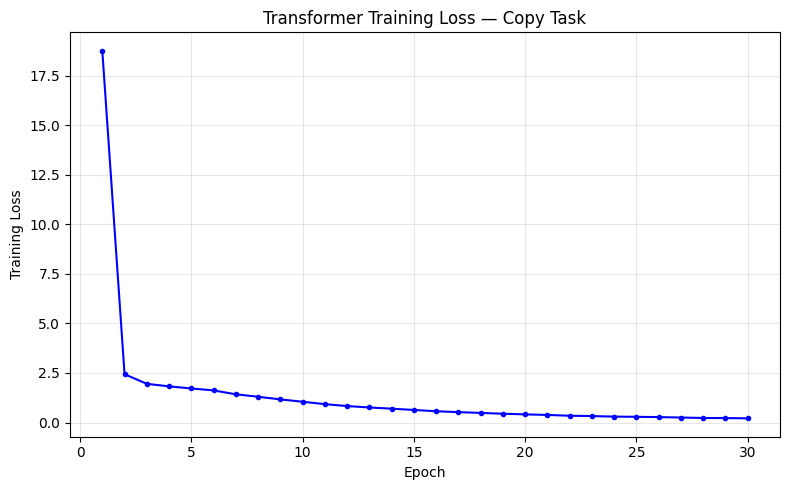

Training loss curve saved.


In [11]:
# Plot training loss curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, NUM_EPOCHS+1), train_losses, 'b-o', markersize=3)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Transformer Training Loss — Copy Task')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print('Training loss curve saved.')

## 11. Evaluation & Inference

We use greedy decoding to generate output sequences and measure copy accuracy.

In [12]:
def evaluate_copy_accuracy(model, dataloader, device):
    """Evaluate exact-sequence copy accuracy."""
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for src, tgt in dataloader:
            src = src.to(device)
            tgt = tgt.to(device)
            
            src_mask = make_pad_mask(src)
            predicted = model.greedy_decode(src, max_len=20, src_mask=src_mask)
            
            # Compare with target (excluding BOS, including EOS)
            target_seq = tgt[:, 1:]  # remove BOS
            
            for i in range(src.size(0)):
                # Get predicted tokens until EOS
                pred = predicted[i].tolist()
                if EOS_TOKEN in pred:
                    pred = pred[:pred.index(EOS_TOKEN)]
                
                # Get target tokens until EOS
                tgt_tokens = target_seq[i].tolist()
                if EOS_TOKEN in tgt_tokens:
                    tgt_tokens = tgt_tokens[:tgt_tokens.index(EOS_TOKEN)]
                
                if pred == tgt_tokens:
                    correct += 1
                total += 1
    
    accuracy = correct / total
    return accuracy

test_accuracy = evaluate_copy_accuracy(model, test_loader, device)
print(f'Test Copy Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.1f}%)')

Test Copy Accuracy: 0.7340 (73.4%)


In [13]:
# Show some example predictions
model.eval()
examples_shown = 0
print('=== Sample Predictions ===\n')

with torch.no_grad():
    for src, tgt in test_loader:
        src = src.to(device)
        src_mask = make_pad_mask(src)
        predicted = model.greedy_decode(src, max_len=20, src_mask=src_mask)
        
        for i in range(min(5 - examples_shown, src.size(0))):
            src_tokens = [t for t in src[i].tolist() if t != PAD_TOKEN]
            pred_tokens = predicted[i].tolist()
            if EOS_TOKEN in pred_tokens:
                pred_tokens = pred_tokens[:pred_tokens.index(EOS_TOKEN)]
            tgt_tokens = [t for t in tgt[i].tolist() if t not in (PAD_TOKEN, BOS_TOKEN, EOS_TOKEN)]
            
            match = '✓' if pred_tokens == tgt_tokens else '✗'
            print(f'{match} Input:    {src_tokens}')
            print(f'  Target:    {tgt_tokens}')
            print(f'  Predicted: {pred_tokens}')
            print()
            examples_shown += 1
        
        if examples_shown >= 5:
            break

=== Sample Predictions ===

✓ Input:    [5, 8, 8, 13, 9, 9]
  Target:    [5, 8, 8, 13, 9, 9]
  Predicted: [5, 8, 8, 13, 9, 9]

✓ Input:    [10, 8, 9, 5, 9, 6, 13, 11]
  Target:    [10, 8, 9, 5, 9, 6, 13, 11]
  Predicted: [10, 8, 9, 5, 9, 6, 13, 11]

✗ Input:    [11, 12, 12, 8, 9, 5]
  Target:    [11, 12, 12, 8, 9, 5]
  Predicted: [11, 12, 8, 12, 9, 5]

✓ Input:    [9, 5, 7, 4, 10, 7, 6, 5, 4, 12]
  Target:    [9, 5, 7, 4, 10, 7, 6, 5, 4, 12]
  Predicted: [9, 5, 7, 4, 10, 7, 6, 5, 4, 12]

✗ Input:    [9, 8, 7, 11, 10, 9, 8, 5]
  Target:    [9, 8, 7, 11, 10, 9, 8, 5]
  Predicted: [9, 8, 7, 11, 10, 9, 5, 8, 5]



## 12. Attention Visualization

Visualize the attention patterns learned by the model:
1. **Encoder self-attention** — how source tokens attend to each other
2. **Decoder-encoder cross-attention** — alignment between decoder and encoder positions
3. **Multi-head patterns** — different heads learning different attention patterns

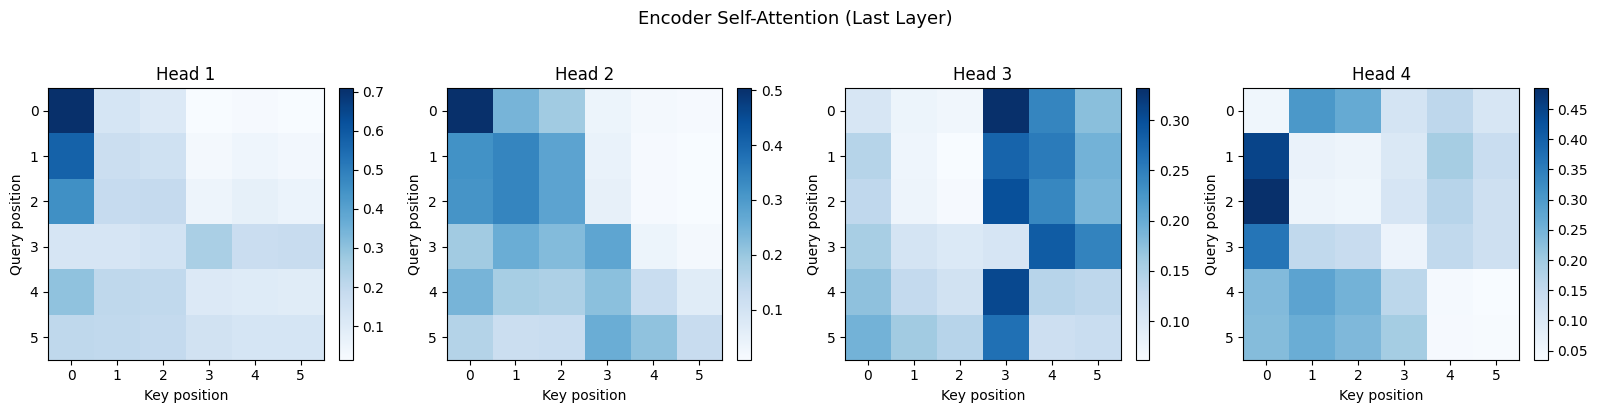

Encoder self-attention heatmap saved.


In [14]:
def plot_attention_heatmap(attn_weights, title, save_path=None):
    """Plot attention weight heatmap.
    attn_weights: (heads, seq_q, seq_k) for a single sample
    """
    num_heads = attn_weights.size(0)
    fig, axes = plt.subplots(1, num_heads, figsize=(4*num_heads, 4))
    if num_heads == 1:
        axes = [axes]
    
    for h in range(num_heads):
        im = axes[h].imshow(attn_weights[h].cpu().numpy(), cmap='Blues', aspect='auto', interpolation='nearest')
        axes[h].set_title(f'Head {h+1}')
        axes[h].set_xlabel('Key position')
        axes[h].set_ylabel('Query position')
        plt.colorbar(im, ax=axes[h], fraction=0.046)
    
    plt.suptitle(title, fontsize=13, y=1.02)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

# Get a sample for visualization
model.eval()
with torch.no_grad():
    src_sample, tgt_sample = test_dataset[0]
    src_sample = src_sample.unsqueeze(0).to(device)
    tgt_sample = tgt_sample.unsqueeze(0).to(device)
    
    src_mask = make_pad_mask(src_sample)
    
    # Forward to capture attention weights
    _ = model(src_sample, tgt_sample[:, :-1], src_mask=src_mask, tgt_mask=make_tgt_mask(tgt_sample[:, :-1]))
    
    src_len = (src_sample[0] != PAD_TOKEN).sum().item()
    tgt_len = (tgt_sample[0] != PAD_TOKEN).sum().item() - 1
    
    # Plot encoder self-attention (last layer)
    enc_attn = model.enc_attn_weights[-1][0]  # (heads, L_src, L_src)
    enc_attn = enc_attn[:, :src_len, :src_len]
    plot_attention_heatmap(enc_attn, 'Encoder Self-Attention (Last Layer)', 'enc_self_attention.png')
    print('Encoder self-attention heatmap saved.')

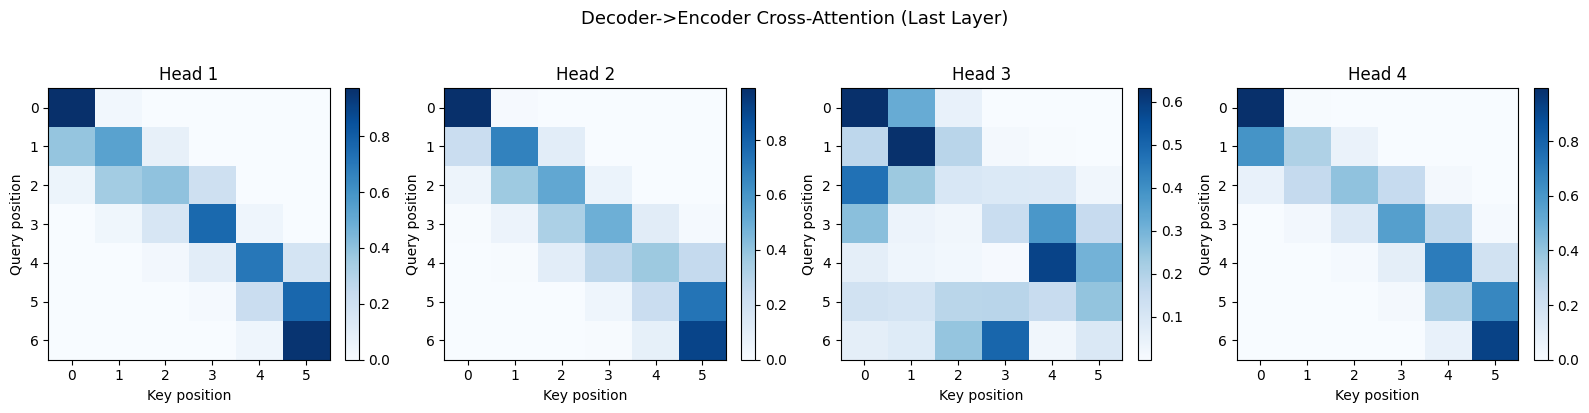

Cross-attention heatmap saved.


In [15]:
# Plot decoder cross-attention (last layer)
model.eval()
with torch.no_grad():
    cross_attn = model.dec_cross_attn_weights[-1][0]  # (heads, L_tgt, L_src)
    cross_attn = cross_attn[:, :tgt_len, :src_len]
    plot_attention_heatmap(cross_attn, 'Decoder->Encoder Cross-Attention (Last Layer)', 'cross_attention.png')
    print('Cross-attention heatmap saved.')

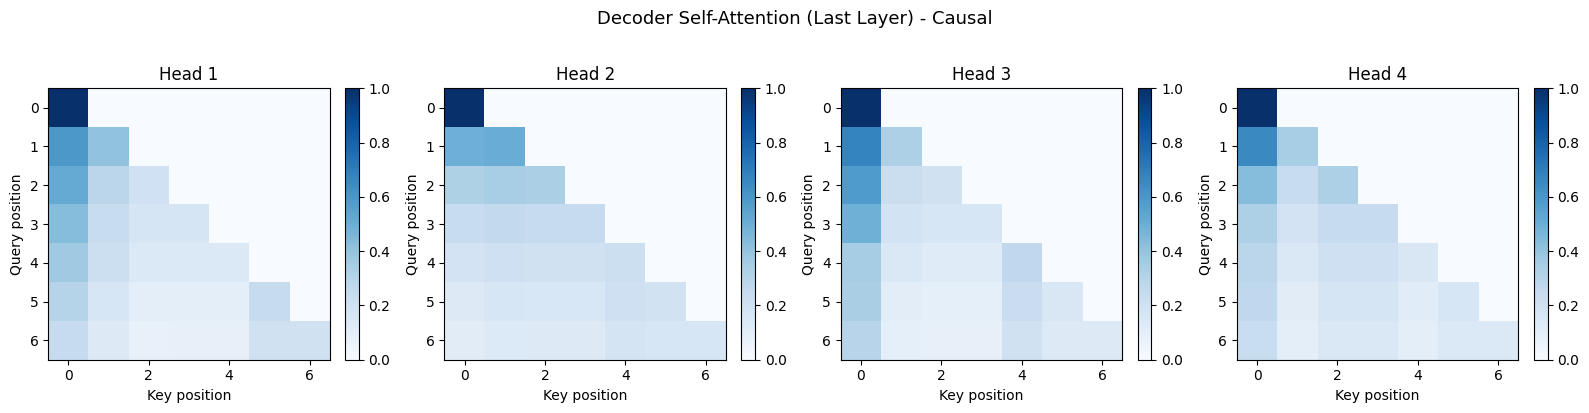

Decoder self-attention heatmap saved.


In [16]:
# Plot decoder self-attention (last layer) — should show causal pattern
model.eval()
with torch.no_grad():
    dec_self_attn = model.dec_self_attn_weights[-1][0]  # (heads, L_tgt, L_tgt)
    dec_self_attn = dec_self_attn[:, :tgt_len, :tgt_len]
    plot_attention_heatmap(dec_self_attn, 'Decoder Self-Attention (Last Layer) - Causal', 'dec_self_attention.png')
    print('Decoder self-attention heatmap saved.')

## Summary

We implemented the complete Transformer architecture from scratch:

- **Scaled dot-product attention** with the 1/√d_k scaling factor
- **Multi-head attention** with learned Q/K/V projections
- **Sinusoidal positional encoding** using sine and cosine functions
- **Encoder layers** (self-attention + FFN with residual + LayerNorm)
- **Decoder layers** (masked self-attention + cross-attention + FFN)
- **Full encoder-decoder model** with weight-tied embeddings
- **Training** with Adam + warmup schedule on a copy task
- **Attention visualization** showing learned patterns across heads

The key insight from the paper — that self-attention alone, without recurrence or convolutions,
is sufficient for high-quality sequence transduction — is demonstrated by the model's ability
to learn the copy task and its attention patterns aligning source and target positions.

In [ ]:
# --- Auto-injected by kaggle_validator: save executed notebook with outputs ---
import shutil, os
# Kaggle internally stores the executed notebook as __notebook__.ipynb
if os.path.exists('/kaggle/working/__notebook__.ipynb'):
    shutil.copy('/kaggle/working/__notebook__.ipynb', '/kaggle/working/executed_solution.ipynb')
    print('Executed notebook saved to output folder.')
else:
    # Fallback: try alternative path
    import glob
    candidates = glob.glob('/kaggle/working/*.ipynb')
    print(f'Available notebooks in output: {candidates}')
